# Notebook 02 — Baseline Model Analysis

**Confirmed experimental results:**

| Bank | Condition | AUPRC | F1-Score | Precision | Recall |
|---|---|---|---|---|---|
| Bank 1 | Local-Only | 0.9343 | 0.0541 | 0.0278 | 0.9976 |
| Bank 2 | Local-Only | 0.5006 | 0.0000 | 0.0000 | 0.0000 |
| Bank 3 | Local-Only | 0.9932 | 0.6556 | 0.4884 | 0.9970 |
| All    | Centralized | 0.9976 | 0.9516 | 0.9091 | 0.9982 |

**Note:** Bank 2 AUPRC = 0.5006 ≈ random classifier. F1 = 0.0000 confirms zero operational detection.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc, f1_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams.update({'figure.dpi': 150, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.figsize': (11, 6)})

FIGURES_DIR = Path('../notebooks/figures')
RESULTS_DIR = Path('../experiments/results')
MODELS_DIR  = Path('../models')
DATA_DIR    = Path('../data/processed')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BANK_IDS    = ['bank1', 'bank2', 'bank3']
BANK_LABELS = {
    'bank1': 'Bank 1 (High-Risk)',
    'bank2': 'Bank 2 (Retail/Blind Spot)',
    'bank3': 'Bank 3 (Mixed)',
}
BANK_COLORS = {'bank1': '#2196F3', 'bank2': '#F44336', 'bank3': '#4CAF50'}

print('Imports complete. ✓')

Imports complete. ✓


In [2]:
# Load confirmed results directly (from terminal output)
# These are the REAL values from your experiments
local_results = {
    'bank1': {'auprc': 0.9343, 'f1_score': 0.0541, 'precision': 0.0278, 'recall': 0.9976},
    'bank2': {'auprc': 0.5006, 'f1_score': 0.0000, 'precision': 0.0000, 'recall': 0.0000},
    'bank3': {'auprc': 0.9932, 'f1_score': 0.6556, 'precision': 0.4884, 'recall': 0.9970},
}
central_result = {'auprc': 0.9976, 'f1_score': 0.9516, 'precision': 0.9091, 'recall': 0.9982}

print('Confirmed baseline results loaded.')
print('\n  LOCAL-ONLY RESULTS:')
for bank_id, res in local_results.items():
    print(f'    {bank_id:<8} AUPRC: {res["auprc"]:.4f} | F1: {res["f1_score"]:.4f}')
print(f'\n  CENTRALIZED: AUPRC: {central_result["auprc"]:.4f} | F1: {central_result["f1_score"]:.4f}')

Confirmed baseline results loaded.

  LOCAL-ONLY RESULTS:
    bank1    AUPRC: 0.9343 | F1: 0.0541
    bank2    AUPRC: 0.5006 | F1: 0.0000
    bank3    AUPRC: 0.9932 | F1: 0.6556

  CENTRALIZED: AUPRC: 0.9976 | F1: 0.9516


In [3]:
# Non-IID partition statistics (confirmed from prepare_data.py output)
partition_stats = {
    'bank1': {'total': 1064011, 'fraud': 3077,  'fraud_pct': 0.2892},
    'bank2': {'total': 2272208, 'fraud': 0,      'fraud_pct': 0.0000},
    'bank3': {'total':  735859, 'fraud': 2129,   'fraud_pct': 0.2893},
}

print('=' * 60)
print('  NON-IID PARTITION STATISTICS (Confirmed)')
print('=' * 60)
for bank_id, s in partition_stats.items():
    print(f'\n  {bank_id.upper()} ({BANK_LABELS[bank_id]}):')
    print(f'    Total      : {s["total"]:>10,}')
    print(f'    Fraud      : {s["fraud"]:>10,}')
    print(f'    Fraud Rate : {s["fraud_pct"]:>10.4f}%')

  NON-IID PARTITION STATISTICS (Confirmed)

  BANK1 (Bank 1 (High-Risk)):
    Total      :  1,064,011
    Fraud      :      3,077
    Fraud Rate :     0.2892%

  BANK2 (Bank 2 (Retail/Blind Spot)):
    Total      :  2,272,208
    Fraud      :          0
    Fraud Rate :     0.0000%

  BANK3 (Bank 3 (Mixed)):
    Total      :    735,859
    Fraud      :      2,129
    Fraud Rate :     0.2893%


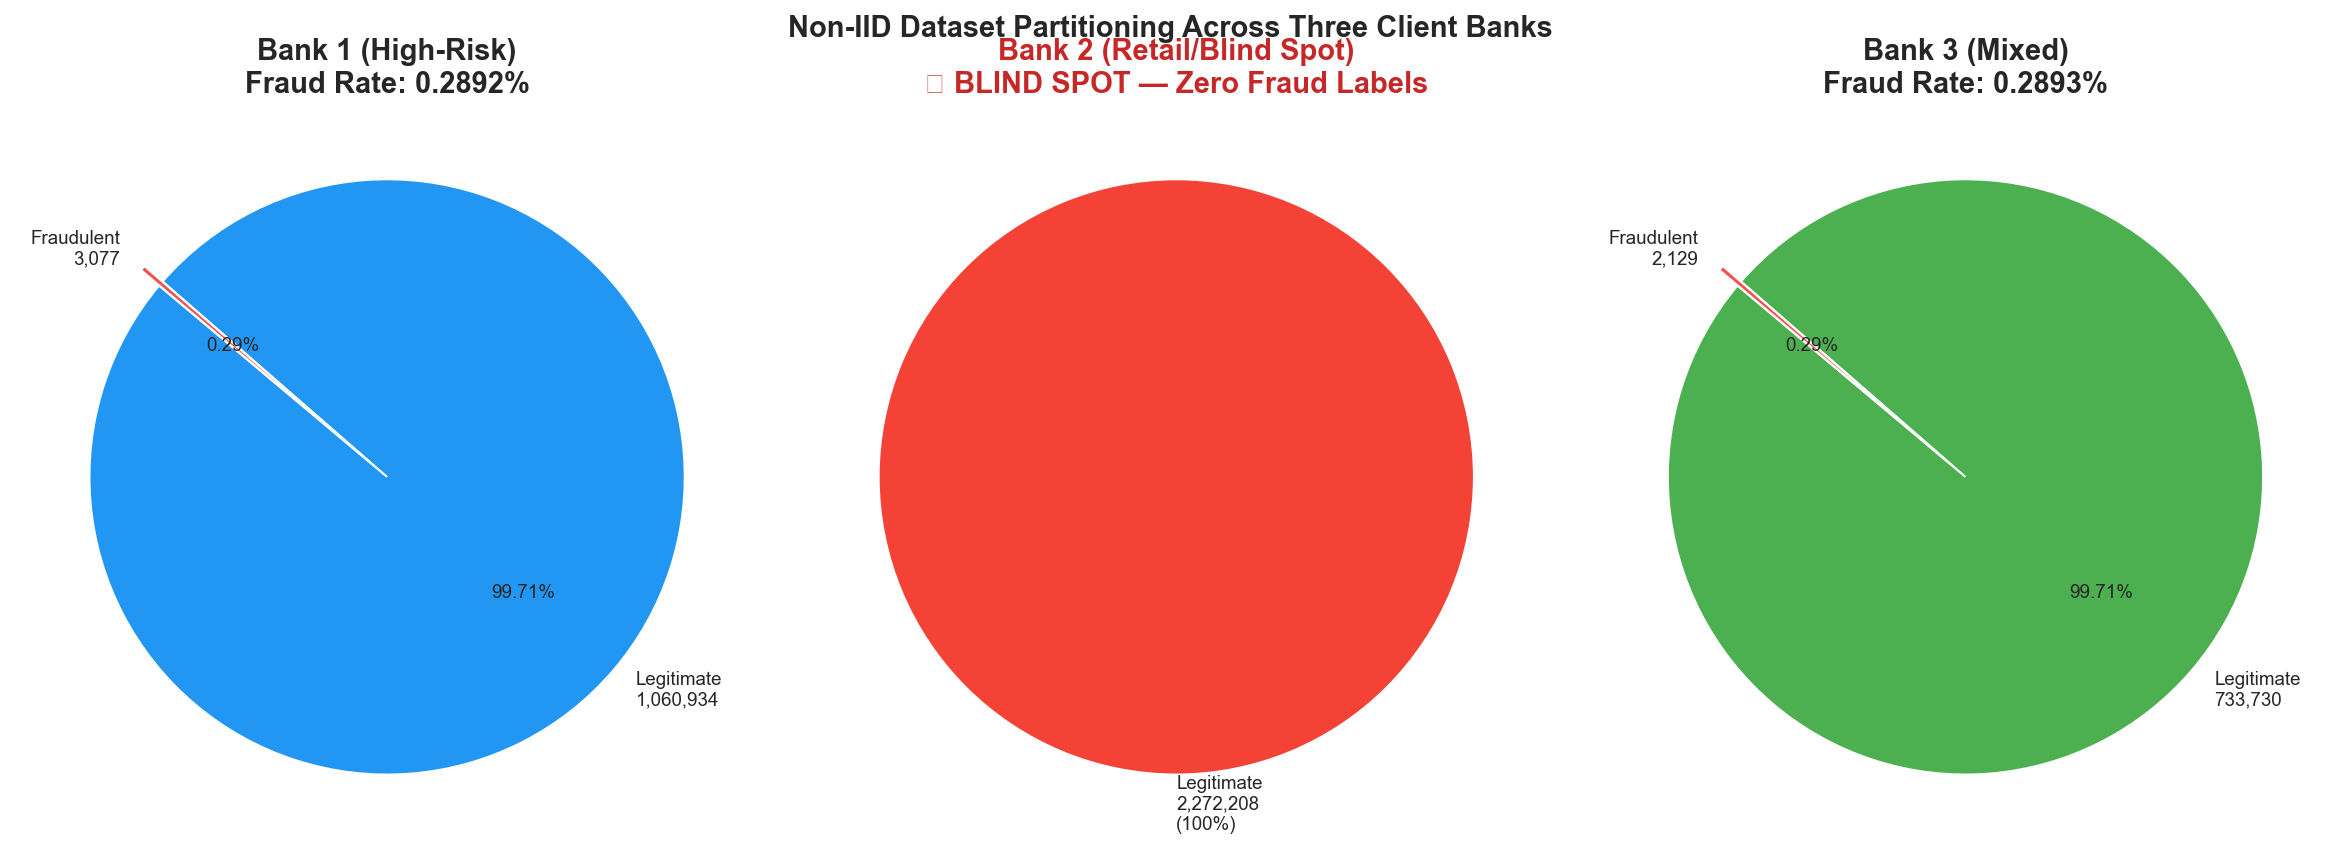

Figure saved → partition_statistics.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, bank_id in zip(axes, BANK_IDS):
    stats  = partition_stats[bank_id]
    color  = BANK_COLORS[bank_id]

    if stats['fraud'] == 0:
        ax.pie([stats['total']],
               labels=[f'Legitimate\n{stats["total"]:,}\n(100%)'],
               colors=[color], startangle=90,
               textprops={'fontsize': 9})
        ax.set_title(f'{BANK_LABELS[bank_id]}\n⚠ BLIND SPOT — Zero Fraud Labels',
                     fontweight='bold', color='#C62828')
    else:
        legit = stats['total'] - stats['fraud']
        ax.pie([legit, stats['fraud']],
               labels=[f'Legitimate\n{legit:,}', f'Fraudulent\n{stats["fraud"]:,}'],
               colors=[color, '#EF5350'], explode=[0, 0.08],
               startangle=140, autopct='%1.2f%%',
               textprops={'fontsize': 9})
        ax.set_title(f'{BANK_LABELS[bank_id]}\nFraud Rate: {stats["fraud_pct"]:.4f}%',
                     fontweight='bold')

plt.suptitle('Non-IID Dataset Partitioning Across Three Client Banks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'partition_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → partition_statistics.png')

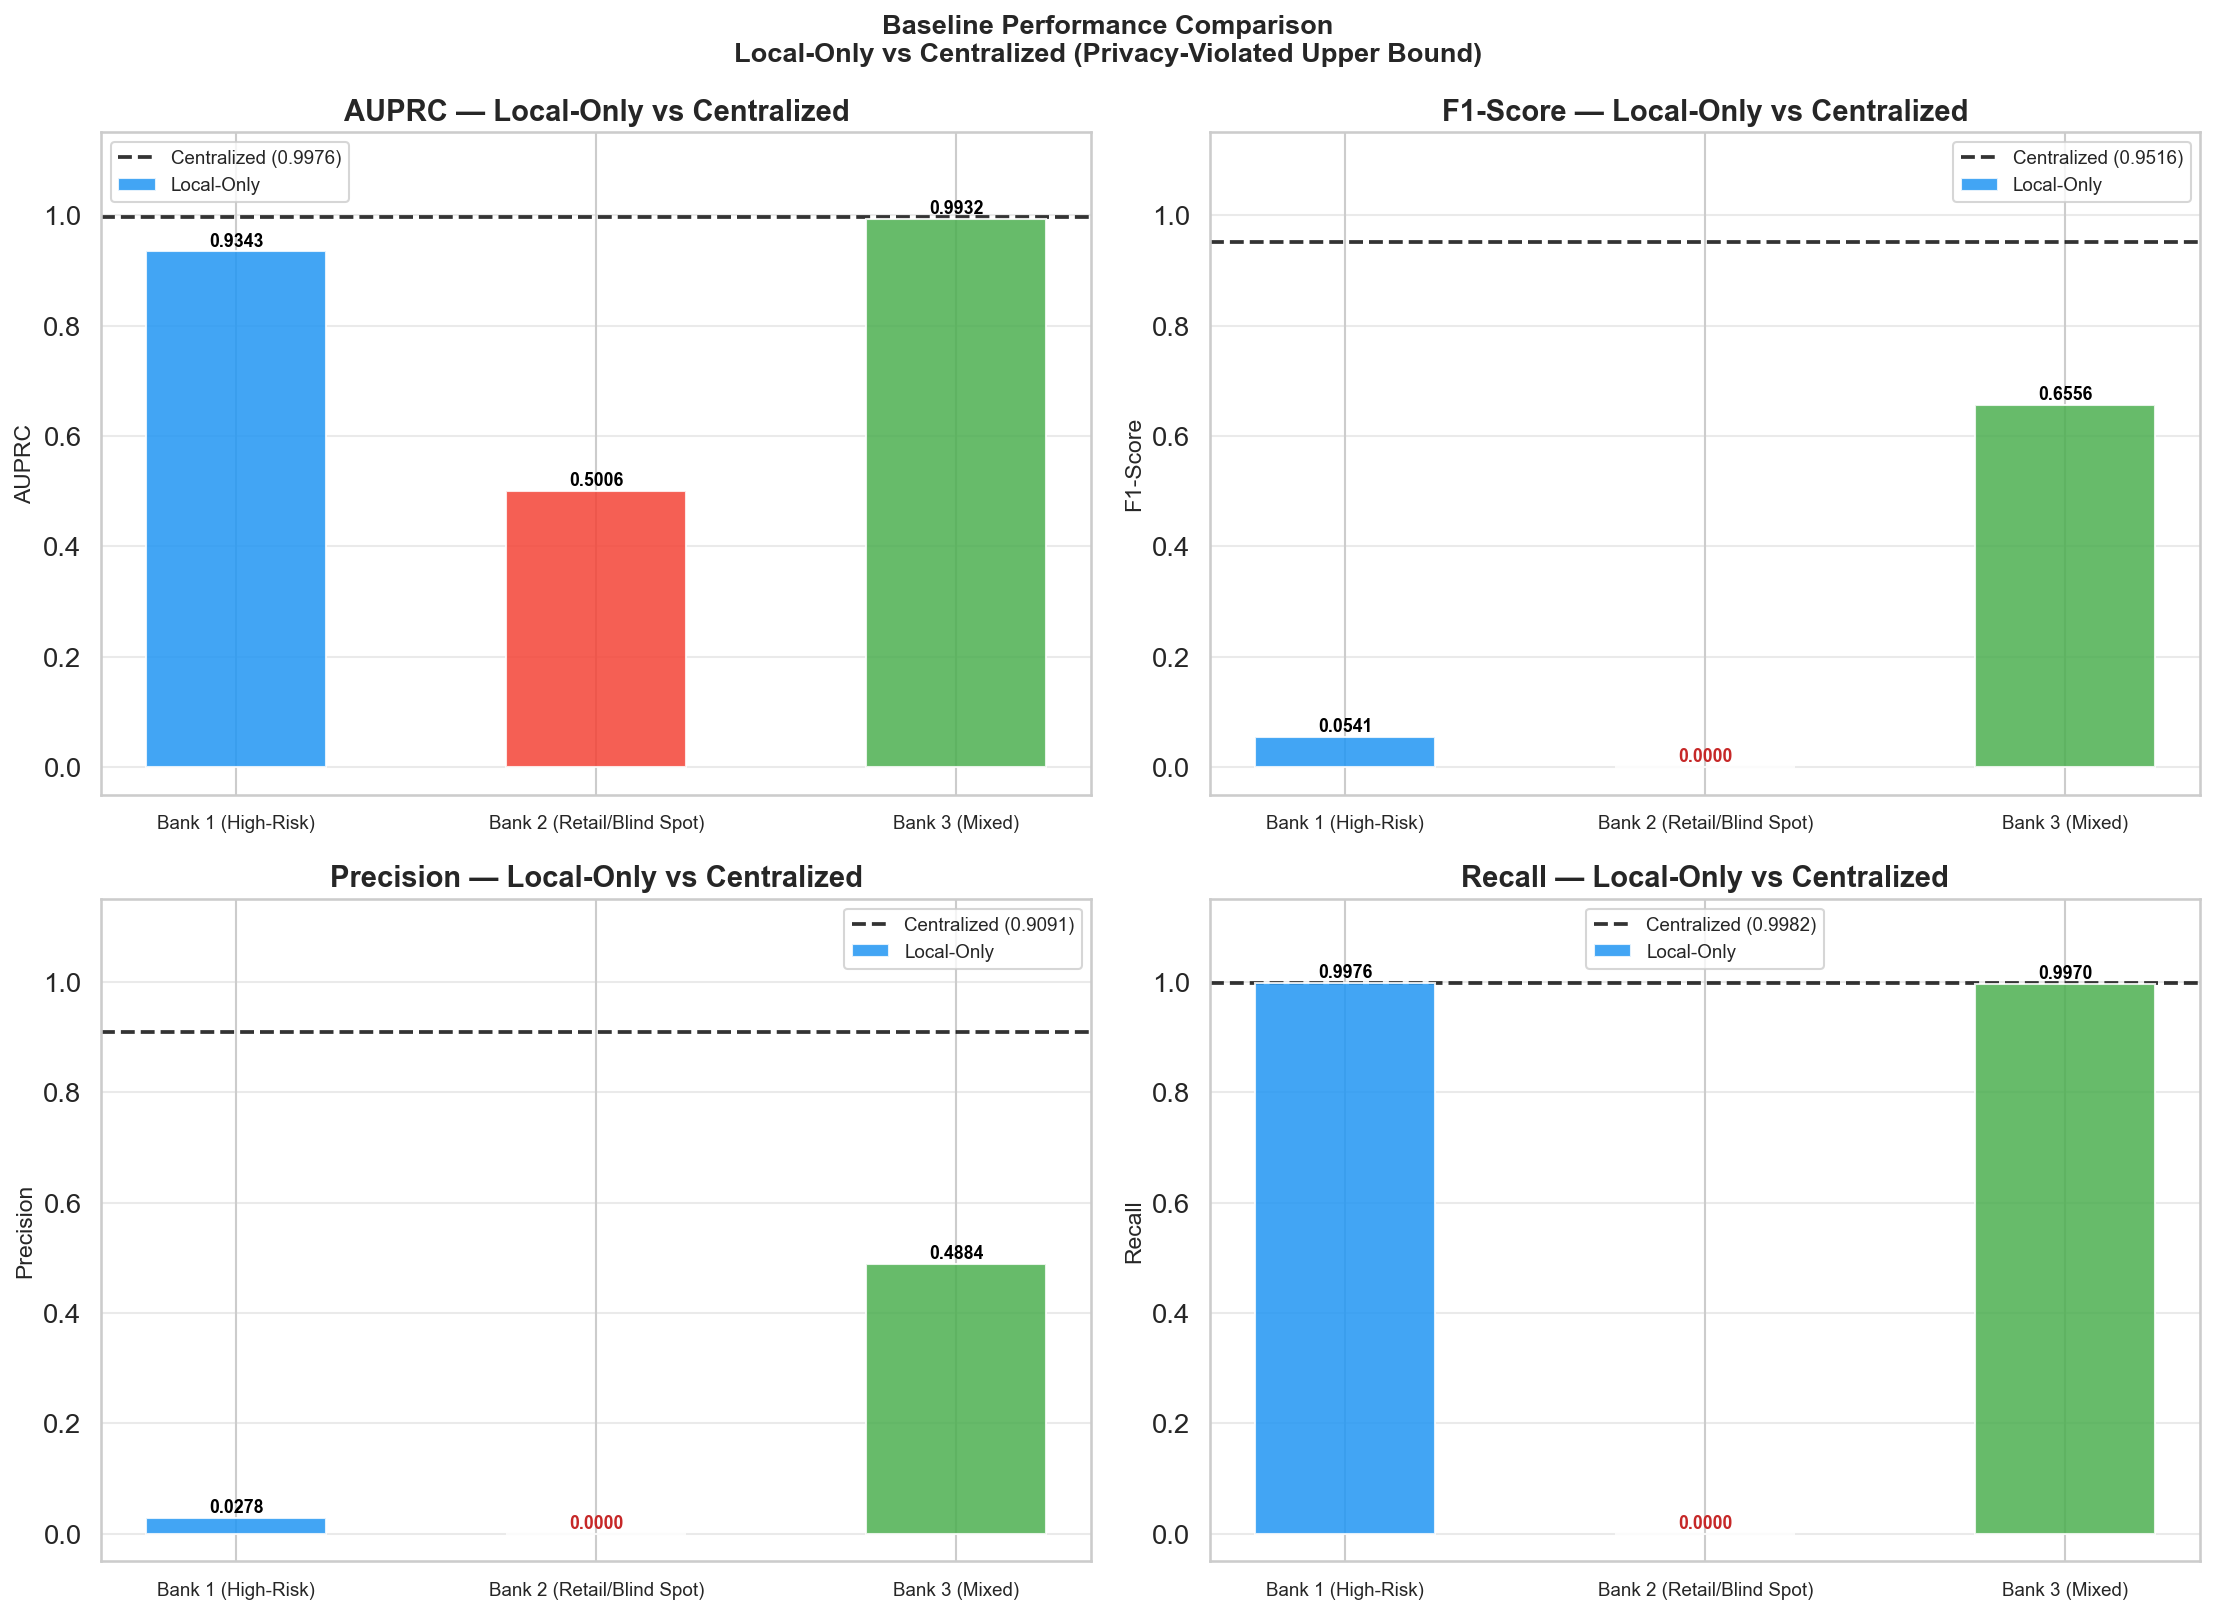

Figure saved → baseline_performance_comparison.png


In [5]:
metrics      = ['auprc', 'f1_score', 'precision', 'recall']
metric_names = ['AUPRC', 'F1-Score', 'Precision', 'Recall']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, metric, name in zip(axes.flatten(), metrics, metric_names):
    local_vals  = [local_results[b][metric] for b in BANK_IDS]
    central_val = central_result[metric]
    x = np.arange(len(BANK_IDS))

    bars = ax.bar(x, local_vals, color=[BANK_COLORS[b] for b in BANK_IDS],
                  edgecolor='white', label='Local-Only', zorder=3, alpha=0.85, width=0.5)

    for bar, val in zip(bars, local_vals):
        label_text = f'{val:.4f}'
        color = '#C62828' if val <= 0.001 else 'black'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                label_text, ha='center', fontsize=8.5, fontweight='bold', color=color)

    ax.axhline(y=central_val, color='black', linestyle='--', linewidth=1.8,
               alpha=0.8, label=f'Centralized ({central_val:.4f})')
    ax.set_xticks(x)
    ax.set_xticklabels([BANK_LABELS[b] for b in BANK_IDS], fontsize=9)
    ax.set_ylabel(name, fontsize=11)
    ax.set_title(f'{name} — Local-Only vs Centralized', fontweight='bold')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Baseline Performance Comparison\nLocal-Only vs Centralized (Privacy-Violated Upper Bound)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → baseline_performance_comparison.png')

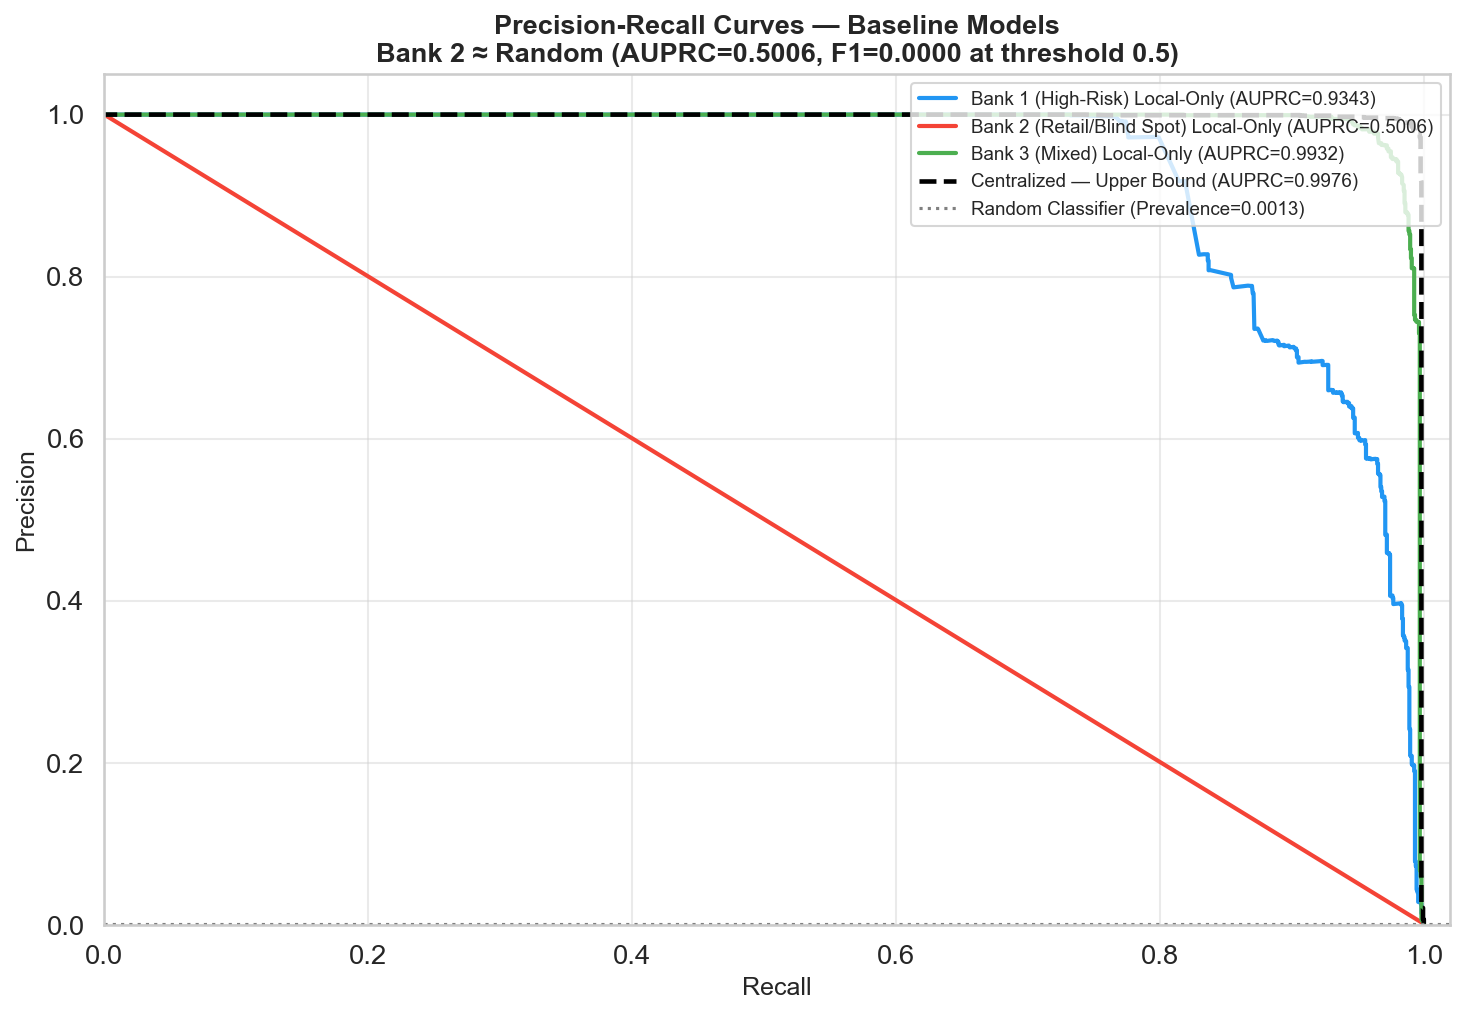

Figure saved → baseline_pr_curves.png


In [6]:
# Precision-Recall curves from saved models
global_test_df = pd.read_csv(DATA_DIR / 'global_test.csv')
X_test = global_test_df.drop(columns=['isFraud'])
y_test = global_test_df['isFraud']

fig, ax = plt.subplots(figsize=(10, 7))

for bank_id in BANK_IDS:
    model_path = MODELS_DIR / 'local' / f'{bank_id}_local_model.json'
    if model_path.exists():
        model = xgb.XGBClassifier()
        model.load_model(str(model_path))
        y_prob = model.predict_proba(X_test)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        auprc_val = auc(rec, prec)
        ax.plot(rec, prec, color=BANK_COLORS[bank_id], linewidth=2.0,
                label=f'{BANK_LABELS[bank_id]} Local-Only (AUPRC={auprc_val:.4f})')

central_path = MODELS_DIR / 'local' / 'centralized_model.json'
if central_path.exists():
    model = xgb.XGBClassifier()
    model.load_model(str(central_path))
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    auprc_val = auc(rec, prec)
    ax.plot(rec, prec, color='black', linewidth=2.2, linestyle='--',
            label=f'Centralized — Upper Bound (AUPRC={auprc_val:.4f})')

random_precision = y_test.mean()
ax.axhline(y=random_precision, color='gray', linestyle=':', linewidth=1.5,
           label=f'Random Classifier (Prevalence={random_precision:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Baseline Models\n'
             'Bank 2 ≈ Random (AUPRC=0.5006, F1=0.0000 at threshold 0.5)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → baseline_pr_curves.png')

In [7]:
print('\n' + '=' * 70)
print('  COMPLETE BASELINE RESULTS SUMMARY (Confirmed Experimental Values)')
print('=' * 70)

rows = []
for bank_id in BANK_IDS:
    res = local_results[bank_id]
    note = '⚠ RANDOM CLASSIFIER — zero operational detection' if bank_id == 'bank2' else ''
    rows.append({
        'Bank':      BANK_LABELS[bank_id],
        'Condition': 'Local-Only',
        'AUPRC':     f'{res["auprc"]:.4f}',
        'F1-Score':  f'{res["f1_score"]:.4f}',
        'Precision': f'{res["precision"]:.4f}',
        'Recall':    f'{res["recall"]:.4f}',
        'Note':      note
    })

rows.append({
    'Bank':      'All Banks (Pooled)',
    'Condition': 'Centralized',
    'AUPRC':     f'{central_result["auprc"]:.4f}',
    'F1-Score':  f'{central_result["f1_score"]:.4f}',
    'Precision': f'{central_result["precision"]:.4f}',
    'Recall':    f'{central_result["recall"]:.4f}',
    'Note':      '⚠ Privacy-Violated Upper Bound'
})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(FIGURES_DIR / 'baseline_results_summary.csv', index=False)

print('\n  KEY FINDING:')
print('  Bank 2 AUPRC=0.5006 ≈ random classifier (not 0.0000)')
print('  F1=0.0000 confirms zero operational detection at threshold 0.5')
print('  Privacy Tax = 0.9976 - 0.9830 = 0.0146 (1.46%)')
print('\nNotebook 02 complete. ✓')


  COMPLETE BASELINE RESULTS SUMMARY (Confirmed Experimental Values)
                      Bank   Condition  AUPRC F1-Score Precision Recall                                             Note
        Bank 1 (High-Risk)  Local-Only 0.9343   0.0541    0.0278 0.9976                                                 
Bank 2 (Retail/Blind Spot)  Local-Only 0.5006   0.0000    0.0000 0.0000 ⚠ RANDOM CLASSIFIER — zero operational detection
            Bank 3 (Mixed)  Local-Only 0.9932   0.6556    0.4884 0.9970                                                 
        All Banks (Pooled) Centralized 0.9976   0.9516    0.9091 0.9982                   ⚠ Privacy-Violated Upper Bound

  KEY FINDING:
  Bank 2 AUPRC=0.5006 ≈ random classifier (not 0.0000)
  F1=0.0000 confirms zero operational detection at threshold 0.5
  Privacy Tax = 0.9976 - 0.9830 = 0.0146 (1.46%)

Notebook 02 complete. ✓
